In [1]:
# STEP 1: DATA INGESTION & VALIDATION

import pandas as pd
import numpy as np



df = pd.read_csv("European_Bank.csv")

# Display first 5 rows
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# 1. Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 14


In [3]:
# 2. Column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [4]:
# 3. Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
# 4. Statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,10000.0,NaN,NaN,NaN,2025.0,0.0,2025.0,2025.0,2025.0,2025.0,2025.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [6]:
# 5. Missing-value validation
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
# 6. Duplicate validation
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# 7. Unique-value analysis
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_summary

,Column,Unique Values
0,Year,1
1,CustomerId,10000
2,Surname,2932
3,CreditScore,460
4,Geography,3
5,Gender,2
6,Age,70
7,Tenure,11
8,Balance,6382
9,NumOfProducts,4


In [9]:
# 8. Validate categorical variables
print("Geography:")
print(df["Geography"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [10]:
# 9. Validate binary variables
binary_columns = ["HasCrCard", "IsActiveMember", "Exited"]

for col in binary_columns:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


HasCrCard:
HasCrCard
0    2945
1    7055
Name: count, dtype: int64

IsActiveMember:
IsActiveMember
0    4849
1    5151
Name: count, dtype: int64

Exited:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [11]:
# 10. Validate target variable
print("Exited distribution:")
print(df["Exited"].value_counts())

print("\nExited percentage:")
print(df["Exited"].value_counts(normalize=True) * 100)

Exited distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Exited percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [12]:
# 11. Validate important numerical ranges
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

for col in numeric_columns:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())


CreditScore
Minimum: 350
Maximum: 850
Mean: 650.5288
Median: 652.0

Age
Minimum: 18
Maximum: 92
Mean: 38.9218
Median: 37.0

Tenure
Minimum: 0
Maximum: 10
Mean: 5.0128
Median: 5.0

Balance
Minimum: 0.0
Maximum: 250898.09
Mean: 76485.889288
Median: 97198.54000000001

NumOfProducts
Minimum: 1
Maximum: 4
Mean: 1.5302
Median: 1.0

EstimatedSalary
Minimum: 11.58
Maximum: 199992.48
Mean: 100090.239881
Median: 100193.915


In [13]:

# 12. Validate the extra Year column
print(df["Year"].value_counts())
print("Number of unique years:", df["Year"].nunique())


Year
2025    10000
Name: count, dtype: int64
Number of unique years: 1


## Step 2 — Data Cleaning & Preparation

In [15]:
# 2.1 — Create a working copy

# Create a working copy of the original dataset
df_cleaned = df.copy()

# Check the shape
print("Original shape:", df.shape)
print("Working dataset shape:", df_cleaned.shape)

Original shape: (10000, 14)
Working dataset shape: (10000, 14)


In [16]:
# 2.2 — Remove non-analytical columns
# Remove non-analytical columns
df_cleaned = df_cleaned.drop(
    columns=["CustomerId", "Surname", "Year"]
)

# Check the remaining columns
print("Remaining columns:")
print(df_cleaned.columns.tolist())

print("\nNew shape:", df_cleaned.shape)

Remaining columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

New shape: (10000, 11)


In [17]:
# Check dataset information after removing non-analytical columns
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [18]:
# Check missing values after cleaning
missing_summary = pd.DataFrame({
    "Missing Values": df_cleaned.isnull().sum(),
    "Missing Percentage": (df_cleaned.isnull().sum() / len(df_cleaned)) * 100
})

missing_summary

,Missing Values,Missing Percentage
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0
HasCrCard,0,0.0
IsActiveMember,0,0.0
EstimatedSalary,0,0.0


In [19]:
# Check duplicate records after removing non-analytical columns
print("Duplicate rows after cleaning:", df_cleaned.duplicated().sum())

Duplicate rows after cleaning: 0


In [20]:
# 2.3 -Validate categorical values
# Validate Geography categories
print("Geography categories:")
print(df_cleaned["Geography"].unique())

# Validate Gender categories
print("\nGender categories:")
print(df_cleaned["Gender"].unique())

Geography categories:
['France' 'Spain' 'Germany']

Gender categories:
['Female' 'Male']


In [21]:
# 2.4 — Validate binary fields
binary_columns = ["HasCrCard", "IsActiveMember", "Exited"]

for col in binary_columns:
    print(f"\n{col} unique values:")
    print(sorted(df_cleaned[col].unique()))


HasCrCard unique values:
[0, 1]

IsActiveMember unique values:
[0, 1]

Exited unique values:
[0, 1]


In [22]:
# 2.5 — Check whether numerical columns contain invalid negative values
non_negative_columns = [
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

for col in non_negative_columns:
    negative_count = (df_cleaned[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

Age: 0 negative values
Tenure: 0 negative values
Balance: 0 negative values
NumOfProducts: 0 negative values
EstimatedSalary: 0 negative values


In [23]:
# 2.6 — Validate logical ranges
# Range validation
print("Age outside 18-100:",
      ((df_cleaned["Age"] < 18) | (df_cleaned["Age"] > 100)).sum())

print("Tenure outside 0-10:",
      ((df_cleaned["Tenure"] < 0) | (df_cleaned["Tenure"] > 10)).sum())

print("NumOfProducts outside 1-4:",
      ((df_cleaned["NumOfProducts"] < 1) | (df_cleaned["NumOfProducts"] > 4)).sum())

print("CreditScore outside 300-850:",
      ((df_cleaned["CreditScore"] < 300) | (df_cleaned["CreditScore"] > 850)).sum())

Age outside 18-100: 0
Tenure outside 0-10: 0
NumOfProducts outside 1-4: 0
CreditScore outside 300-850: 0


In [24]:
# 2.7 — Check data types
# Check data types
print(df_cleaned.dtypes)

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [25]:
# 2.8 -Create a final cleaning summary
cleaning_summary = pd.DataFrame({
    "Data Type": df_cleaned.dtypes,
    "Missing Values": df_cleaned.isnull().sum(),
    "Unique Values": df_cleaned.nunique()
})

cleaning_summary

,Data Type,Missing Values,Unique Values
CreditScore,int64,0,460
Geography,object,0,3
Gender,object,0,2
Age,int64,0,70
Tenure,int64,0,11
Balance,float64,0,6382
NumOfProducts,int64,0,4
HasCrCard,int64,0,2
IsActiveMember,int64,0,2
EstimatedSalary,float64,0,9999


## Step 3 — Customer Segmentation Design

In [27]:
# 3.1 — Create a working copy
df_seg = df_cleaned.copy()

print("Dataset shape:", df_seg.shape)


Dataset shape: (10000, 11)


In [28]:
# 3.2 — Geography Segmentation
# Geography segmentation
df_seg["Geography_Segment"] = df_seg["Geography"]

print(df_seg["Geography_Segment"].value_counts())

Geography_Segment
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [29]:
geography_summary = pd.DataFrame({
    "Customers": df_seg["Geography_Segment"].value_counts(),
    "Percentage": df_seg["Geography_Segment"].value_counts(normalize=True) * 100
})

geography_summary

,Customers,Percentage
Geography_Segment,,
France,5014,50.14
Germany,2509,25.09
Spain,2477,24.77


In [30]:
# 3.3 — Age Segmentation
# Age segmentation
df_seg["Age_Segment"] = pd.cut(
    df_seg["Age"],
    bins=[0, 29, 45, 60, np.inf],
    labels=["<30", "30–45", "46–60", "60+"],
    right=True
)

print(df_seg["Age_Segment"].value_counts().sort_index())

Age_Segment
<30      1641
30–45    6248
46–60    1647
60+       464
Name: count, dtype: int64


In [31]:
age_summary = pd.DataFrame({
    "Customers": df_seg["Age_Segment"].value_counts().sort_index(),
    "Percentage": df_seg["Age_Segment"].value_counts(normalize=True).sort_index() * 100
})

age_summary

,Customers,Percentage
Age_Segment,,
<30,1641,16.41
30–45,6248,62.48
46–60,1647,16.47
60+,464,4.64


In [32]:
# 3.4 — Inspect Credit Score Distribution
# Credit score distribution
credit_score_summary = df_seg["CreditScore"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

credit_score_summary

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
10%        521.000000
25%        584.000000
50%        652.000000
75%        718.000000
90%        778.000000
max        850.000000
Name: CreditScore, dtype: float64

In [33]:
# Credit score bands for inspection only
credit_bins = [0, 500, 600, 700, 800, 900]

credit_check = pd.cut(
    df_seg["CreditScore"],
    bins=credit_bins,
    right=False
)

print(credit_check.value_counts().sort_index())

CreditScore
[0, 500)       632
[500, 600)    2402
[600, 700)    3818
[700, 800)    2493
[800, 900)     655
Name: count, dtype: int64


In [34]:
# 3.5 — Inspect Tenure Distribution
# Tenure distribution
tenure_counts = df_seg["Tenure"].value_counts().sort_index()

tenure_counts

Tenure
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: count, dtype: int64

In [35]:
tenure_percentage = df_seg["Tenure"].value_counts(
    normalize=True
).sort_index() * 100

tenure_percentage

Tenure
0      4.13
1     10.35
2     10.48
3     10.09
4      9.89
5     10.12
6      9.67
7     10.28
8     10.25
9      9.84
10     4.90
Name: proportion, dtype: float64

In [36]:
df_seg["Tenure"].describe()

count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Tenure, dtype: float64

In [37]:
# 3.6 — Inspect Balance Distribution
# Zero balance analysis
zero_balance_count = (df_seg["Balance"] == 0).sum()

print("Zero-balance customers:", zero_balance_count)
print(
    "Zero-balance percentage:",
    round((zero_balance_count / len(df_seg)) * 100, 2)
)

Zero-balance customers: 3617
Zero-balance percentage: 36.17


In [38]:
# Positive balance statistics
positive_balance = df_seg.loc[df_seg["Balance"] > 0, "Balance"]

positive_balance.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90]
)

count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
90%      157755.568000
max      250898.090000
Name: Balance, dtype: float64

In [39]:
balance_percentiles = positive_balance.quantile(
    [0.25, 0.50, 0.75, 0.90]
)

balance_percentiles

0.25    100181.975
0.50    119839.690
0.75    139512.290
0.90    157755.568
Name: Balance, dtype: float64

In [40]:
balance_check = pd.cut(
    df_seg["Balance"],
    bins=[-1, 0, 50000, 100000, 150000, 200000, np.inf],
    right=True
)

balance_check.value_counts().sort_index()

Balance
(-1.0, 0.0]             3617
(0.0, 50000.0]            75
(50000.0, 100000.0]     1509
(100000.0, 150000.0]    3830
(150000.0, 200000.0]     935
(200000.0, inf]           34
Name: count, dtype: int64

In [41]:
# 3.7 — Check Segmentation Inputs Together
segmentation_inputs = pd.DataFrame({
    "Variable": [
        "CreditScore",
        "Age",
        "Tenure",
        "Balance"
    ],
    "Minimum": [
        df_seg["CreditScore"].min(),
        df_seg["Age"].min(),
        df_seg["Tenure"].min(),
        df_seg["Balance"].min()
    ],
    "Median": [
        df_seg["CreditScore"].median(),
        df_seg["Age"].median(),
        df_seg["Tenure"].median(),
        df_seg["Balance"].median()
    ],
    "Maximum": [
        df_seg["CreditScore"].max(),
        df_seg["Age"].max(),
        df_seg["Tenure"].max(),
        df_seg["Balance"].max()
    ]
})

segmentation_inputs

,Variable,Minimum,Median,Maximum
0,CreditScore,350.0,652.00,850.00
1,Age,18.0,37.00,92.00
2,Tenure,0.0,5.00,10.00
3,Balance,0.0,97198.54,250898.09


In [42]:
# 3.8 — Validate Whether Any Customer Is Left Unassigned
print("Missing Geography segments:", df_seg["Geography_Segment"].isna().sum())
print("Missing Age segments:", df_seg["Age_Segment"].isna().sum())

Missing Geography segments: 0
Missing Age segments: 0


## Step 4 — Churn Distribution Analysis

In [44]:
# 4.1 — Create Credit Score Segments
# Create Credit Score segments

df_seg["CreditScore_Segment"] = pd.cut(
    df_seg["CreditScore"],
    bins=[-np.inf, 599, 699, np.inf],
    labels=["Low", "Medium", "High"]
)

print(df_seg["CreditScore_Segment"].value_counts().sort_index())

CreditScore_Segment
Low       3034
Medium    3818
High      3148
Name: count, dtype: int64


In [45]:
credit_score_segment_summary = pd.DataFrame({
    "Customers": df_seg["CreditScore_Segment"].value_counts().sort_index(),
    "Percentage": (
        df_seg["CreditScore_Segment"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

credit_score_segment_summary

,Customers,Percentage
CreditScore_Segment,,
Low,3034,30.34
Medium,3818,38.18
High,3148,31.48


In [46]:
# 4.2 — Create Tenure Segments
# Create Tenure segments

df_seg["Tenure_Segment"] = pd.cut(
    df_seg["Tenure"],
    bins=[-1, 3, 6, 10],
    labels=["New", "Mid-term", "Long-term"]
)

print(df_seg["Tenure_Segment"].value_counts().sort_index())

Tenure_Segment
New          3505
Mid-term     2968
Long-term    3527
Name: count, dtype: int64


In [47]:
tenure_segment_summary = pd.DataFrame({
    "Customers": df_seg["Tenure_Segment"].value_counts().sort_index(),
    "Percentage": (
        df_seg["Tenure_Segment"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

tenure_segment_summary

,Customers,Percentage
Tenure_Segment,,
New,3505,35.05
Mid-term,2968,29.68
Long-term,3527,35.27


In [48]:
# 4.3 — Create Balance Segments
# Median positive balance
positive_balance_median = df_seg.loc[
    df_seg["Balance"] > 0, "Balance"
].median()

print("Median positive balance:", positive_balance_median)

Median positive balance: 119839.69


In [64]:
# ==========================================
# STEP 4.3: CREATE BALANCE SEGMENTS
# ==========================================

# Median of positive balances
positive_balance_median = df_seg.loc[
    df_seg["Balance"] > 0, "Balance"
].median()

print("Median positive balance:", positive_balance_median)

# Create balance segments
df_seg["Balance_Segment"] = np.select(
    [
        df_seg["Balance"] == 0,
        (df_seg["Balance"] > 0) &
        (df_seg["Balance"] <= positive_balance_median),
        df_seg["Balance"] > positive_balance_median
    ],
    [
        "Zero-balance",
        "Low-balance",
        "High-balance"
    ],
    default="Unassigned"
)

# Check segment distribution
print("\nBalance segment distribution:")
print(df_seg["Balance_Segment"].value_counts())

Median positive balance: 119839.69

Balance segment distribution:
Balance_Segment
Zero-balance    3617
Low-balance     3192
High-balance    3191
Name: count, dtype: int64


In [66]:
# Check whether any customer remains unassigned
print(
    "Unassigned customers:",
    (df_seg["Balance_Segment"] == "Unassigned").sum()
)

Unassigned customers: 0


In [68]:
balance_segment_summary = pd.DataFrame({
    "Customers": df_seg["Balance_Segment"].value_counts(),
    "Percentage": (
        df_seg["Balance_Segment"]
        .value_counts(normalize=True) * 100
    )
})

balance_segment_summary

,Customers,Percentage
Balance_Segment,,
Zero-balance,3617,36.17
Low-balance,3192,31.92
High-balance,3191,31.91


In [70]:
# 4.4 — Validate All Segmentation Columns
segment_columns = [
    "Geography_Segment",
    "Age_Segment",
    "CreditScore_Segment",
    "Tenure_Segment",
    "Balance_Segment"
]

for col in segment_columns:
    print(f"{col}: {df_seg[col].isna().sum()} unassigned customers")

Geography_Segment: 0 unassigned customers
Age_Segment: 0 unassigned customers
CreditScore_Segment: 0 unassigned customers
Tenure_Segment: 0 unassigned customers
Balance_Segment: 0 unassigned customers


In [72]:
# 4.5 — Check the Final Dataset
print("Shape:", df_seg.shape)

print("\nColumns:")
print(df_seg.columns.tolist())

Shape: (10000, 16)

Columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Segment', 'Age_Segment', 'CreditScore_Segment', 'Tenure_Segment', 'Balance_Segment']


In [74]:
# 4.6 — Overall Churn Analysis
# Overall churn summary

total_customers = len(df_seg)

churned_customers = (df_seg["Exited"] == 1).sum()

retained_customers = (df_seg["Exited"] == 0).sum()

overall_churn_rate = (
    churned_customers / total_customers
) * 100

overall_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Overall Churn Rate (%)"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        overall_churn_rate
    ]
})

overall_summary

,Metric,Value
0,Total Customers,10000.00
1,Churned Customers,2037.00
2,Retained Customers,7963.00
3,Overall Churn Rate (%),20.37


In [76]:
# 4.7 — Overall Churn Distribution
churn_distribution = pd.DataFrame({
    "Customers": df_seg["Exited"].value_counts().sort_index()
})

churn_distribution["Percentage"] = (
    df_seg["Exited"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

churn_distribution.index = ["Retained", "Churned"]

churn_distribution

,Customers,Percentage
Retained,7963,79.63
Churned,2037,20.37


In [78]:
# 4.8 — Geography-wise Churn Analysis
geography_churn = (
    df_seg.groupby("Geography_Segment", observed=True)
    .agg(
        Total_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

geography_churn["Retained_Customers"] = (
    geography_churn["Total_Customers"]
    - geography_churn["Churned_Customers"]
)

geography_churn["Churn_Rate_%"] = (
    geography_churn["Churned_Customers"]
    / geography_churn["Total_Customers"]
) * 100

geography_churn["Churn_Contribution_%"] = (
    geography_churn["Churned_Customers"]
    / churned_customers
) * 100

geography_churn = geography_churn.round(2)

geography_churn

,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
Geography_Segment,,,,,
France,5014,810,4204,16.15,39.76
Germany,2509,814,1695,32.44,39.96
Spain,2477,413,2064,16.67,20.27


In [80]:
# 4.9 — Age-wise Churn Analysis
age_churn = (
    df_seg.groupby("Age_Segment", observed=True)
    .agg(
        Total_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

age_churn["Retained_Customers"] = (
    age_churn["Total_Customers"]
    - age_churn["Churned_Customers"]
)

age_churn["Churn_Rate_%"] = (
    age_churn["Churned_Customers"]
    / age_churn["Total_Customers"]
) * 100

age_churn["Churn_Contribution_%"] = (
    age_churn["Churned_Customers"]
    / churned_customers
) * 100

age_churn = age_churn.round(2)

age_churn

,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
Age_Segment,,,,,
<30,1641,124,1517,7.56,6.09
30–45,6248,956,5292,15.30,46.93
46–60,1647,842,805,51.12,41.34
60+,464,115,349,24.78,5.65


In [82]:
# 4.10 — Credit Score-wise Churn Analysis
credit_churn = (
    df_seg.groupby("CreditScore_Segment", observed=True)
    .agg(
        Total_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

credit_churn["Retained_Customers"] = (
    credit_churn["Total_Customers"]
    - credit_churn["Churned_Customers"]
)

credit_churn["Churn_Rate_%"] = (
    credit_churn["Churned_Customers"]
    / credit_churn["Total_Customers"]
) * 100

credit_churn["Churn_Contribution_%"] = (
    credit_churn["Churned_Customers"]
    / churned_customers
) * 100

credit_churn = credit_churn.round(2)

credit_churn

,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
CreditScore_Segment,,,,,
Low,3034,660,2374,21.75,32.40
Medium,3818,753,3065,19.72,36.97
High,3148,624,2524,19.82,30.63


In [84]:
# 4.11 — Tenure-wise Churn Analysis
tenure_churn = (
    df_seg.groupby("Tenure_Segment", observed=True)
    .agg(
        Total_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

tenure_churn["Retained_Customers"] = (
    tenure_churn["Total_Customers"]
    - tenure_churn["Churned_Customers"]
)

tenure_churn["Churn_Rate_%"] = (
    tenure_churn["Churned_Customers"]
    / tenure_churn["Total_Customers"]
) * 100

tenure_churn["Churn_Contribution_%"] = (
    tenure_churn["Churned_Customers"]
    / churned_customers
) * 100

tenure_churn = tenure_churn.round(2)

tenure_churn

,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
Tenure_Segment,,,,,
New,3505,741,2764,21.14,36.38
Mid-term,2968,608,2360,20.49,29.85
Long-term,3527,688,2839,19.51,33.78


In [86]:
# 4.12 — Balance-wise Churn Analysis
balance_churn = (
    df_seg.groupby("Balance_Segment", observed=True)
    .agg(
        Total_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

balance_churn["Retained_Customers"] = (
    balance_churn["Total_Customers"]
    - balance_churn["Churned_Customers"]
)

balance_churn["Churn_Rate_%"] = (
    balance_churn["Churned_Customers"]
    / balance_churn["Total_Customers"]
) * 100

balance_churn["Churn_Contribution_%"] = (
    balance_churn["Churned_Customers"]
    / churned_customers
) * 100

balance_churn = balance_churn.round(2)

balance_churn

,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
Balance_Segment,,,,,
High-balance,3191,771,2420,24.16,37.85
Low-balance,3192,766,2426,24.00,37.60
Zero-balance,3617,500,3117,13.82,24.55


In [88]:
# 4.13 — Compare Segment Churn Rate With Overall Churn
def add_churn_comparison(summary_df):
    result = summary_df.copy()

    result["Difference_vs_Overall_pp"] = (
        result["Churn_Rate_%"] - overall_churn_rate
    )

    result["Relative_Churn_Index"] = (
        result["Churn_Rate_%"] / overall_churn_rate
    )

    return result.round(2)

In [90]:
geography_churn_comparison

NameError: name 'geography_churn_comparison' is not defined

In [92]:
# 4.14 — Create One Combined Segment Summary
segment_churn_summary = pd.concat([
    geography_churn.assign(Segment_Type="Geography")
                   .rename_axis("Segment")
                   .reset_index(),

    age_churn.assign(Segment_Type="Age")
             .rename_axis("Segment")
             .reset_index(),

    credit_churn.assign(Segment_Type="Credit Score")
                 .rename_axis("Segment")
                 .reset_index(),

    tenure_churn.assign(Segment_Type="Tenure")
                 .rename_axis("Segment")
                 .reset_index(),

    balance_churn.assign(Segment_Type="Balance")
                  .rename_axis("Segment")
                  .reset_index()
], ignore_index=True)

segment_churn_summary = segment_churn_summary[
    [
        "Segment_Type",
        "Segment",
        "Total_Customers",
        "Churned_Customers",
        "Retained_Customers",
        "Churn_Rate_%",
        "Churn_Contribution_%"
    ]
]

segment_churn_summary

,Segment_Type,Segment,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
0,Geography,France,5014,810,4204,16.15,39.76
1,Geography,Germany,2509,814,1695,32.44,39.96
2,Geography,Spain,2477,413,2064,16.67,20.27
3,Age,<30,1641,124,1517,7.56,6.09
4,Age,30–45,6248,956,5292,15.30,46.93
5,Age,46–60,1647,842,805,51.12,41.34
6,Age,60+,464,115,349,24.78,5.65
7,Credit Score,Low,3034,660,2374,21.75,32.40
8,Credit Score,Medium,3818,753,3065,19.72,36.97
9,Credit Score,High,3148,624,2524,19.82,30.63


## Step 5 — Comparative Demographic Analysis

In [95]:
# ==========================================
# STEP 5.1: GENDER-BASED CHURN ANALYSIS
# ==========================================

gender_churn = (
    df_seg.groupby("Gender")
    .agg(
        Total_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

gender_churn["Retained_Customers"] = (
    gender_churn["Total_Customers"]
    - gender_churn["Churned_Customers"]
)

gender_churn["Churn_Rate_%"] = (
    gender_churn["Churned_Customers"]
    / gender_churn["Total_Customers"]
) * 100

gender_churn["Churn_Contribution_%"] = (
    gender_churn["Churned_Customers"]
    / df_seg["Exited"].sum()
) * 100

gender_churn["Difference_vs_Overall_pp"] = (
    gender_churn["Churn_Rate_%"]
    - overall_churn_rate
)

gender_churn = gender_churn.round(2)

gender_churn

,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%,Difference_vs_Overall_pp
Gender,,,,,,
Female,4543,1139,3404,25.07,55.92,4.70
Male,5457,898,4559,16.46,44.08,-3.91


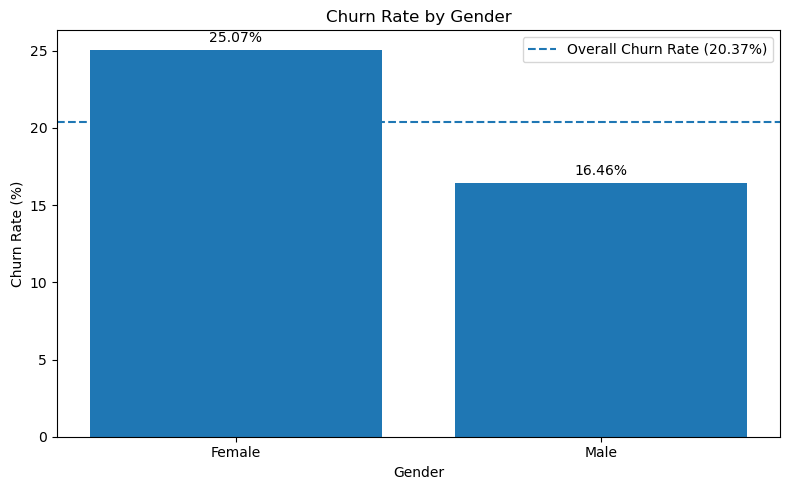

In [97]:
# 5.2 — Gender Churn Rate Chart
import matplotlib.pyplot as plt

# Gender churn rate
plt.figure(figsize=(8, 5))

bars = plt.bar(
    gender_churn.index,
    gender_churn["Churn_Rate_%"]
)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn Rate ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.legend()

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

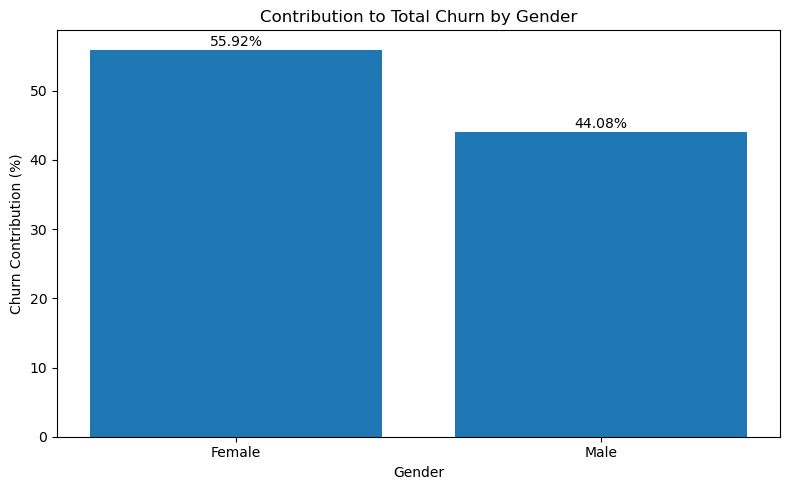

In [98]:
# 5.3 — Gender Churn Contribution Chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    gender_churn.index,
    gender_churn["Churn_Contribution_%"]
)

plt.title("Contribution to Total Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Contribution (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [99]:
# 5.4 — Geography × Age Interaction
# ==========================================
# STEP 5.4: GEOGRAPHY × AGE ANALYSIS
# ==========================================

geo_age_churn = (
    df_seg.groupby(
        ["Geography_Segment", "Age_Segment"],
        observed=True
    )
    .agg(
        Total_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

geo_age_churn["Retained_Customers"] = (
    geo_age_churn["Total_Customers"]
    - geo_age_churn["Churned_Customers"]
)

geo_age_churn["Churn_Rate_%"] = (
    geo_age_churn["Churned_Customers"]
    / geo_age_churn["Total_Customers"]
) * 100

geo_age_churn["Churn_Contribution_%"] = (
    geo_age_churn["Churned_Customers"]
    / df_seg["Exited"].sum()
) * 100

geo_age_churn = geo_age_churn.round(2)

geo_age_churn

Total_Customers  Churned_Customers  \
Geography_Segment Age_Segment                                       
France            <30                      866                 45   
                  30–45                   3168                376   
                  46–60                    749                343   
                  60+                      231                 46   
Germany           <30                      372                 47   
                  30–45                   1522                385   
                  46–60                    502                338   
                  60+                      113                 44   
Spain             <30                      403                 32   
                  30–45                   1558                195   
                  46–60                    396                161   
                  60+                      120                 25   

                               Retained_Customers  Churn_Rate_%  \
Geography_Segment Age_Segment                                     
France            <30                         821          5.20   
                  30–45                      2792         11.87   
                  46–60                       406         45.79   
                  60+                         185         19.91   
Germany           <30                         325         12.63   
                  30–45                      1137         25.30   
                  46–60                       164         67.33   
                  60+                          69         38.94   
Spain             <30                         371          7.94   
                  30–45                      1363         12.52   
                  46–60                       235         40.66   
                  60+                          95         20.83   

                               Churn_Contribution_%  
Geography_Segment Age_Segment                        
France            <30                          2.21  
                  30–45                       18.46  
                  46–60                       16.84  
                  60+                          2.26  
Germany           <30                          2.31  
                  30–45                       18.90  
                  46–60                       16.59  
                  60+                          2.16  
Spain             <30                          1.57  
                  30–45                        9.57  
                  46–60                        7.90  
                  60+                          1.23

In [100]:
# 5.5 — Geography × Age Churn Matrix
geo_age_rate = geo_age_churn["Churn_Rate_%"].unstack()

geo_age_rate

Age_Segment,<30,30–45,46–60,60+
Geography_Segment,,,,
France,5.20,11.87,45.79,19.91
Germany,12.63,25.30,67.33,38.94
Spain,7.94,12.52,40.66,20.83


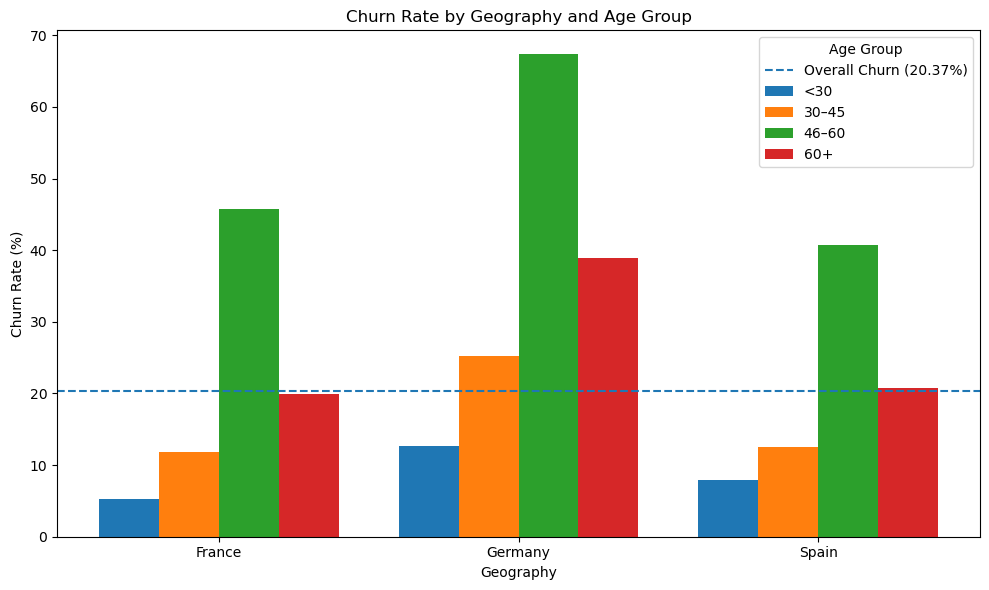

In [101]:
# 5.6 — Geography × Age Grouped Bar Chart
plt.figure(figsize=(10, 6))

x = np.arange(len(geo_age_rate.index))
width = 0.2

for i, age_group in enumerate(geo_age_rate.columns):
    plt.bar(
        x + (i - 1.5) * width,
        geo_age_rate[age_group],
        width,
        label=age_group
    )

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.2f}%)"
)

plt.xticks(x, geo_age_rate.index)
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Geography and Age Group")
plt.legend(title="Age Group")

plt.tight_layout()
plt.show()

In [102]:
# 5.7 — Find the Highest-Churn Geography × Age Segments
geo_age_rank = (
    geo_age_churn
    .sort_values("Churn_Rate_%", ascending=False)
    .reset_index()
)

geo_age_rank

,Geography_Segment,Age_Segment,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
0,Germany,46–60,502,338,164,67.33,16.59
1,France,46–60,749,343,406,45.79,16.84
2,Spain,46–60,396,161,235,40.66,7.90
3,Germany,60+,113,44,69,38.94,2.16
4,Germany,30–45,1522,385,1137,25.30,18.90
5,Spain,60+,120,25,95,20.83,1.23
6,France,60+,231,46,185,19.91,2.26
7,Germany,<30,372,47,325,12.63,2.31
8,Spain,30–45,1558,195,1363,12.52,9.57
9,France,30–45,3168,376,2792,11.87,18.46


In [107]:
# 5.8 — Geography × Age Customer Volume
geo_age_population = (
    df_seg.groupby(
        ["Geography_Segment", "Age_Segment"],
        observed=True
    )
    .size()
    .unstack()
)

geo_age_population

Age_Segment,<30,30–45,46–60,60+
Geography_Segment,,,,
France,866,3168,749,231
Germany,372,1522,502,113
Spain,403,1558,396,120


In [111]:
# 5.9 — Financial Stability vs Churn
#inancial stability vs churn

"""We already have:

Credit Score segments
Balance segments

We will now analyse the actual financial characteristics of churned vs retained customers."""

'We already have:\n\nCredit Score segments\nBalance segments\n\nWe will now analyse the actual financial characteristics of churned vs retained customers.'

In [113]:
# ==========================================
# STEP 5.10: FINANCIAL PROFILE COMPARISON
# ==========================================

financial_profile = (
    df_seg.groupby("Exited")
    .agg(
        Average_CreditScore=("CreditScore", "mean"),
        Median_CreditScore=("CreditScore", "median"),
        Average_Balance=("Balance", "mean"),
        Median_Balance=("Balance", "median"),
        Average_Salary=("EstimatedSalary", "mean"),
        Median_Salary=("EstimatedSalary", "median")
    )
)

financial_profile.index = ["Retained", "Churned"]

financial_profile = financial_profile.round(2)

financial_profile

,Average_CreditScore,Median_CreditScore,Average_Balance,Median_Balance,Average_Salary,Median_Salary
Retained,651.85,653.0,72745.30,92072.68,99738.39,99645.04
Churned,645.35,646.0,91108.54,109349.29,101465.68,102460.84


In [115]:
# 5.11 — Financial Profile Difference
financial_difference = pd.DataFrame({
    "Metric": [
        "Average Credit Score",
        "Median Credit Score",
        "Average Balance",
        "Median Balance",
        "Average Salary",
        "Median Salary"
    ],
    "Retained": [
        financial_profile.loc["Retained", "Average_CreditScore"],
        financial_profile.loc["Retained", "Median_CreditScore"],
        financial_profile.loc["Retained", "Average_Balance"],
        financial_profile.loc["Retained", "Median_Balance"],
        financial_profile.loc["Retained", "Average_Salary"],
        financial_profile.loc["Retained", "Median_Salary"]
    ],
    "Churned": [
        financial_profile.loc["Churned", "Average_CreditScore"],
        financial_profile.loc["Churned", "Median_CreditScore"],
        financial_profile.loc["Churned", "Average_Balance"],
        financial_profile.loc["Churned", "Median_Balance"],
        financial_profile.loc["Churned", "Average_Salary"],
        financial_profile.loc["Churned", "Median_Salary"]
    ]
})

financial_difference["Difference"] = (
    financial_difference["Churned"]
    - financial_difference["Retained"]
)

financial_difference.round(2)

,Metric,Retained,Churned,Difference
0,Average Credit Score,651.85,645.35,-6.50
1,Median Credit Score,653.00,646.00,-7.00
2,Average Balance,72745.30,91108.54,18363.24
3,Median Balance,92072.68,109349.29,17276.61
4,Average Salary,99738.39,101465.68,1727.29
5,Median Salary,99645.04,102460.84,2815.80


In [117]:
#5.12 — Churn Rate by Balance Segment
balance_financial = (
    df_seg.groupby("Balance_Segment")
    .agg(
        Customers=("Exited", "size"),
        Churned=("Exited", "sum")
    )
)

balance_financial["Churn_Rate_%"] = (
    balance_financial["Churned"]
    / balance_financial["Customers"]
) * 100

balance_financial = balance_financial.round(2)

balance_financial

,Customers,Churned,Churn_Rate_%
Balance_Segment,,,
High-balance,3191,771,24.16
Low-balance,3192,766,24.00
Zero-balance,3617,500,13.82


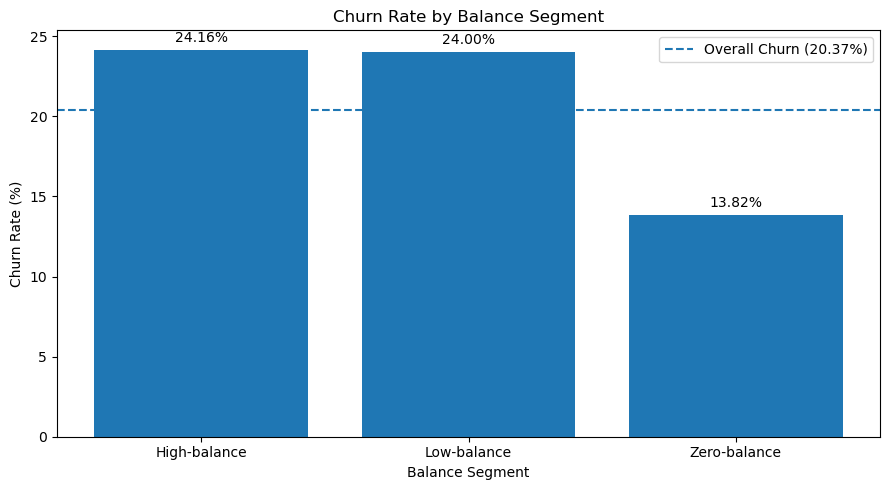

In [119]:
# 5.13 — Balance Segment Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    balance_financial.index,
    balance_financial["Churn_Rate_%"]
)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Balance Segment")
plt.xlabel("Balance Segment")
plt.ylabel("Churn Rate (%)")
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

C:\Users\artsa\AppData\Local\Temp\ipykernel_5968\3892996840.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


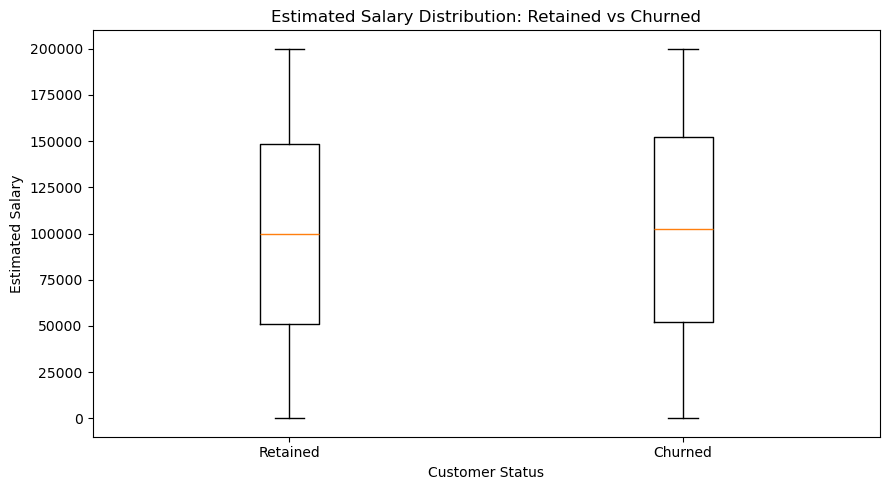

In [121]:
#5.14 — Salary Distribution: Churned vs Retained
plt.figure(figsize=(9, 5))

plt.boxplot(
    [
        df_seg.loc[df_seg["Exited"] == 0, "EstimatedSalary"],
        df_seg.loc[df_seg["Exited"] == 1, "EstimatedSalary"]
    ],
    labels=["Retained", "Churned"]
)

plt.title("Estimated Salary Distribution: Retained vs Churned")
plt.xlabel("Customer Status")
plt.ylabel("Estimated Salary")

plt.tight_layout()
plt.show()

C:\Users\artsa\AppData\Local\Temp\ipykernel_5968\3411517428.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


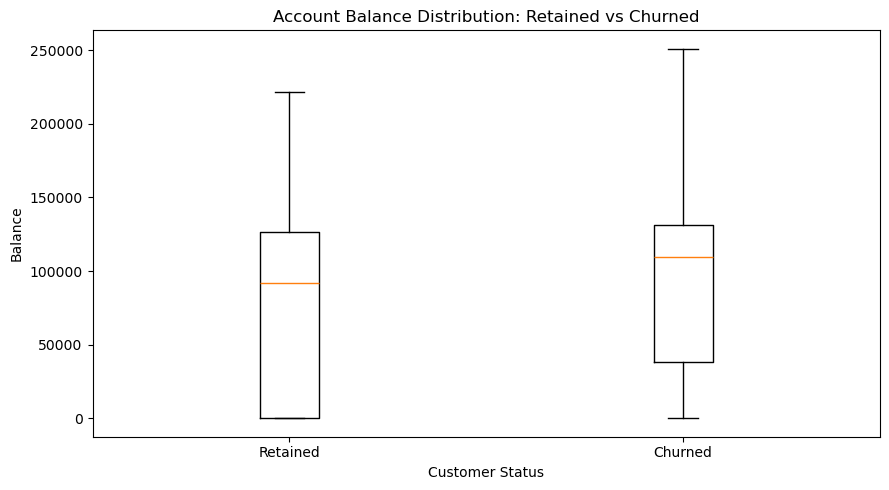

In [123]:
# 5.15 — Balance Distribution: Churned vs Retained
plt.figure(figsize=(9, 5))

plt.boxplot(
    [
        df_seg.loc[df_seg["Exited"] == 0, "Balance"],
        df_seg.loc[df_seg["Exited"] == 1, "Balance"]
    ],
    labels=["Retained", "Churned"]
)

plt.title("Account Balance Distribution: Retained vs Churned")
plt.xlabel("Customer Status")
plt.ylabel("Balance")

plt.tight_layout()
plt.show()

In [125]:
# 5.16 — Financial Stability Summary
financial_stability_summary = (
    df_seg.groupby(["Balance_Segment", "CreditScore_Segment"], observed=True)
    .agg(
        Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

financial_stability_summary["Churn_Rate_%"] = (
    financial_stability_summary["Churned_Customers"]
    / financial_stability_summary["Customers"]
) * 100

financial_stability_summary = (
    financial_stability_summary
    .round(2)
    .reset_index()
)

financial_stability_summary

,Balance_Segment,CreditScore_Segment,Customers,Churned_Customers,Churn_Rate_%
0,High-balance,Low,982,246,25.05
1,High-balance,Medium,1216,293,24.10
2,High-balance,High,993,232,23.36
3,Low-balance,Low,928,251,27.05
4,Low-balance,Medium,1239,273,22.03
5,Low-balance,High,1025,242,23.61
6,Zero-balance,Low,1124,163,14.50
7,Zero-balance,Medium,1363,187,13.72
8,Zero-balance,High,1130,150,13.27


In [127]:
# 5.17 — Find the Most Important Financial
financial_stability_rank = (
    financial_stability_summary
    .sort_values(
        "Churn_Rate_%",
        ascending=False
    )
)

financial_stability_rank

,Balance_Segment,CreditScore_Segment,Customers,Churned_Customers,Churn_Rate_%
3,Low-balance,Low,928,251,27.05
0,High-balance,Low,982,246,25.05
1,High-balance,Medium,1216,293,24.10
5,Low-balance,High,1025,242,23.61
2,High-balance,High,993,232,23.36
4,Low-balance,Medium,1239,273,22.03
6,Zero-balance,Low,1124,163,14.50
7,Zero-balance,Medium,1363,187,13.72
8,Zero-balance,High,1130,150,13.27


In [129]:
# 5.18 — One Final Validation
print("Gender rows:", len(gender_churn))

print("Geography × Age combinations:",
      len(geo_age_churn))

print("Financial profile rows:",
      len(financial_profile))

print("Financial stability combinations:",
      len(financial_stability_summary))

Gender rows: 2
Geography × Age combinations: 12
Financial profile rows: 2
Financial stability combinations: 9


## 6.1 — Create High-Value Customer Flag

In [132]:
# ==========================================
# STEP 6.1: HIGH-VALUE CUSTOMER FLAG
# ==========================================

df_seg["High_Value_Flag"] = np.where(
    df_seg["Balance_Segment"] == "High-balance",
    "High-Value",
    "Non-High-Value"
)

print(df_seg["High_Value_Flag"].value_counts())

High_Value_Flag
Non-High-Value    6809
High-Value        3191
Name: count, dtype: int64


In [134]:
high_value_distribution = pd.DataFrame({
    "Customers": df_seg["High_Value_Flag"].value_counts(),
    "Percentage": (
        df_seg["High_Value_Flag"]
        .value_counts(normalize=True) * 100
    )
})

high_value_distribution

,Customers,Percentage
High_Value_Flag,,
Non-High-Value,6809,68.09
High-Value,3191,31.91


In [136]:
# ==========================================
# STEP 6.2: HIGH-VALUE KPI SUMMARY
# ==========================================

high_value_summary = (
    df_seg.groupby("High_Value_Flag")
    .agg(
        Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum"),
        Total_Balance=("Balance", "sum"),
        Average_Balance=("Balance", "mean"),
        Average_Salary=("EstimatedSalary", "mean")
    )
)

high_value_summary["Churn_Rate_%"] = (
    high_value_summary["Churned_Customers"]
    / high_value_summary["Customers"]
) * 100

high_value_summary = high_value_summary.round(2)

high_value_summary

,Customers,Churned_Customers,Total_Balance,Average_Balance,Average_Salary,Churn_Rate_%
High_Value_Flag,,,,,,
High-Value,3191,771,4.581541e+08,143576.95,100769.02,24.16
Non-High-Value,6809,1266,3.067048e+08,45044.03,99772.13,18.59


In [138]:
# 6.3 — High-Value vs Non-High-Value Churn
high_value_churn = (
    df_seg.groupby("High_Value_Flag")
    .agg(
        Total_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

high_value_churn["Retained_Customers"] = (
    high_value_churn["Total_Customers"]
    - high_value_churn["Churned_Customers"]
)

high_value_churn["Churn_Rate_%"] = (
    high_value_churn["Churned_Customers"]
    / high_value_churn["Total_Customers"]
) * 100

high_value_churn["Churn_Contribution_%"] = (
    high_value_churn["Churned_Customers"]
    / df_seg["Exited"].sum()
) * 100

high_value_churn = high_value_churn.round(2)

high_value_churn

,Total_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
High_Value_Flag,,,,,
High-Value,3191,771,2420,24.16,37.85
Non-High-Value,6809,1266,5543,18.59,62.15


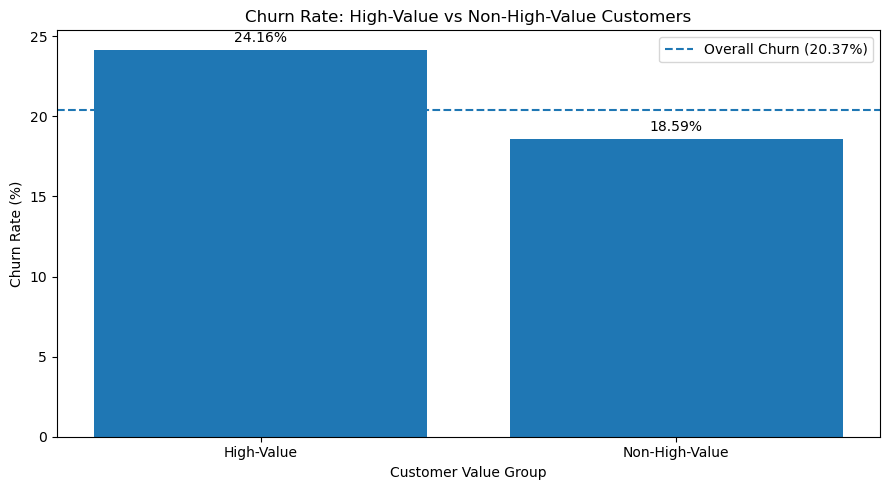

In [140]:
# 6.4 — Chart: High-Value vs Non-High-Value Churn Rate
plt.figure(figsize=(9, 5))

bars = plt.bar(
    high_value_churn.index,
    high_value_churn["Churn_Rate_%"]
)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate: High-Value vs Non-High-Value Customers")
plt.xlabel("Customer Value Group")
plt.ylabel("Churn Rate (%)")
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

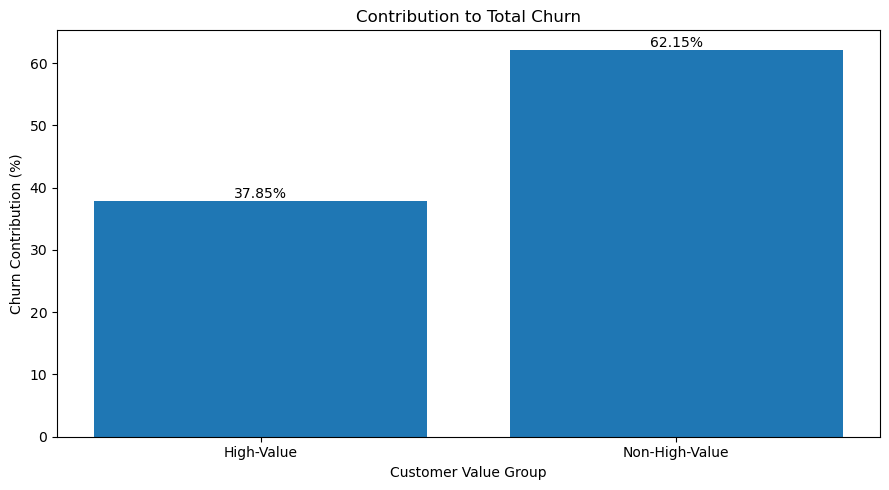

In [142]:
# 6.5 — Chart: High-Value Customer Churn Contribution
plt.figure(figsize=(9, 5))

bars = plt.bar(
    high_value_churn.index,
    high_value_churn["Churn_Contribution_%"]
)

plt.title("Contribution to Total Churn")
plt.xlabel("Customer Value Group")
plt.ylabel("Churn Contribution (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [144]:
# ==========================================
# STEP 6.6: HIGH-VALUE CHURN BY GEOGRAPHY
# ==========================================

high_value_geo = (
    df_seg[df_seg["High_Value_Flag"] == "High-Value"]
    .groupby("Geography_Segment")
    .agg(
        High_Value_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

high_value_geo["Retained_Customers"] = (
    high_value_geo["High_Value_Customers"]
    - high_value_geo["Churned_Customers"]
)

high_value_geo["Churn_Rate_%"] = (
    high_value_geo["Churned_Customers"]
    / high_value_geo["High_Value_Customers"]
) * 100

high_value_geo["Churn_Contribution_%"] = (
    high_value_geo["Churned_Customers"]
    / high_value_geo["Churned_Customers"].sum()
) * 100

high_value_geo = high_value_geo.round(2)

high_value_geo

,High_Value_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
Geography_Segment,,,,,
France,1308,257,1051,19.65,33.33
Germany,1248,394,854,31.57,51.10
Spain,635,120,515,18.90,15.56


In [146]:
# ==========================================
# STEP 6.8: HIGH-VALUE CHURN BY AGE
# ==========================================

high_value_age = (
    df_seg[df_seg["High_Value_Flag"] == "High-Value"]
    .groupby("Age_Segment", observed=True)
    .agg(
        High_Value_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

high_value_age["Retained_Customers"] = (
    high_value_age["High_Value_Customers"]
    - high_value_age["Churned_Customers"]
)

high_value_age["Churn_Rate_%"] = (
    high_value_age["Churned_Customers"]
    / high_value_age["High_Value_Customers"]
) * 100

high_value_age["Churn_Contribution_%"] = (
    high_value_age["Churned_Customers"]
    / high_value_age["Churned_Customers"].sum()
) * 100

high_value_age = high_value_age.round(2)

high_value_age

,High_Value_Customers,Churned_Customers,Retained_Customers,Churn_Rate_%,Churn_Contribution_%
Age_Segment,,,,,
<30,510,58,452,11.37,7.52
30–45,1982,366,1616,18.47,47.47
46–60,549,302,247,55.01,39.17
60+,150,45,105,30.00,5.84


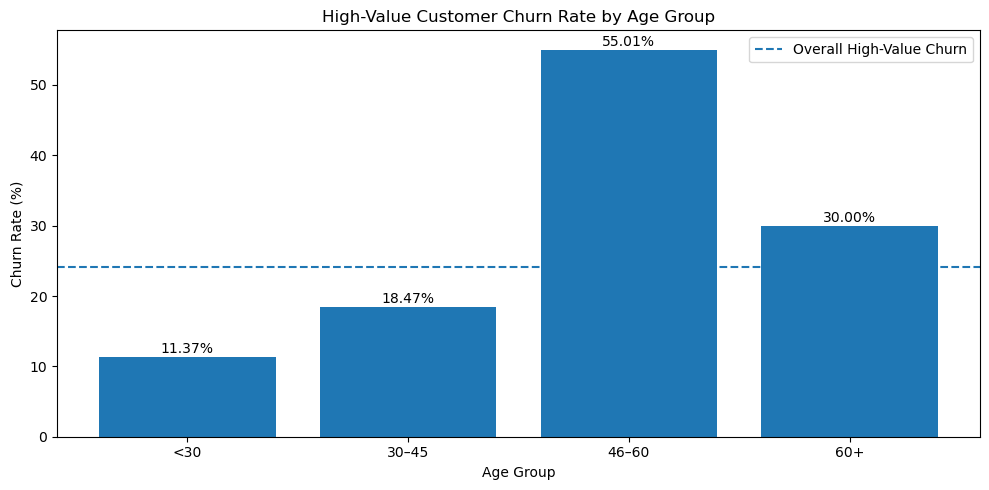

In [148]:
# 6.9 — Chart: High-Value Churn by Age
plt.figure(figsize=(10, 5))

bars = plt.bar(
    high_value_age.index.astype(str),
    high_value_age["Churn_Rate_%"]
)

plt.axhline(
    high_value_churn.loc["High-Value", "Churn_Rate_%"],
    linestyle="--",
    label="Overall High-Value Churn"
)

plt.title("High-Value Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [150]:
# 6.10 — High-Value Churn by Gender
# ==========================================
# STEP 6.10: HIGH-VALUE CHURN BY GENDER
# ==========================================

high_value_gender = (
    df_seg[df_seg["High_Value_Flag"] == "High-Value"]
    .groupby("Gender")
    .agg(
        High_Value_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

high_value_gender["Churn_Rate_%"] = (
    high_value_gender["Churned_Customers"]
    / high_value_gender["High_Value_Customers"]
) * 100

high_value_gender = high_value_gender.round(2)

high_value_gender

,High_Value_Customers,Churned_Customers,Churn_Rate_%
Gender,,,
Female,1411,416,29.48
Male,1780,355,19.94


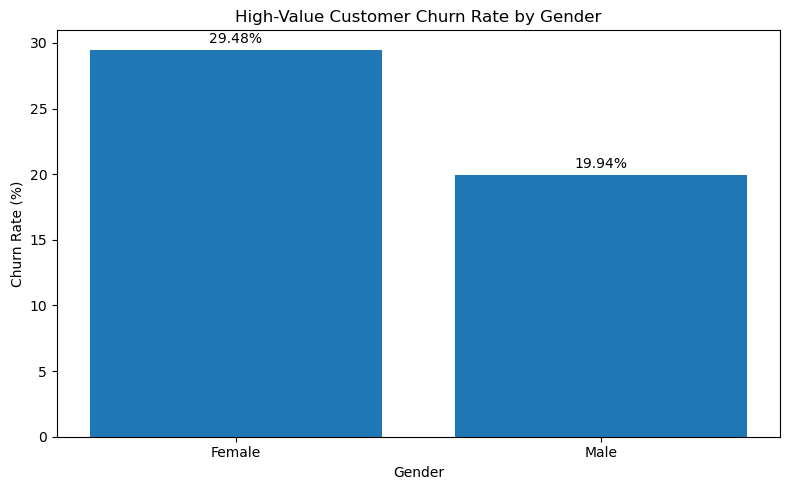

In [152]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    high_value_gender.index,
    high_value_gender["Churn_Rate_%"]
)

plt.title("High-Value Customer Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [154]:
# 6.11 — High-Value Churn by Customer Activity
# ==========================================
# STEP 6.11: HIGH-VALUE CHURN BY ACTIVITY
# ==========================================

activity_labels = {
    0: "Inactive",
    1: "Active"
}

df_seg["Activity_Group"] = df_seg["IsActiveMember"].map(activity_labels)

high_value_activity = (
    df_seg[df_seg["High_Value_Flag"] == "High-Value"]
    .groupby("Activity_Group")
    .agg(
        High_Value_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

high_value_activity["Churn_Rate_%"] = (
    high_value_activity["Churned_Customers"]
    / high_value_activity["High_Value_Customers"]
) * 100

high_value_activity = high_value_activity.round(2)

high_value_activity

,High_Value_Customers,Churned_Customers,Churn_Rate_%
Activity_Group,,,
Active,1622,281,17.32
Inactive,1569,490,31.23


In [156]:
# 6.12 — High-Value Churn by Number of Products
# ==========================================
# STEP 6.12: HIGH-VALUE CHURN BY PRODUCTS
# ==========================================

high_value_products = (
    df_seg[df_seg["High_Value_Flag"] == "High-Value"]
    .groupby("NumOfProducts")
    .agg(
        High_Value_Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

high_value_products["Churn_Rate_%"] = (
    high_value_products["Churned_Customers"]
    / high_value_products["High_Value_Customers"]
) * 100

high_value_products = high_value_products.round(2)

high_value_products

,High_Value_Customers,Churned_Customers,Churn_Rate_%
NumOfProducts,,,
1,2093,546,26.09
2,991,124,12.51
3,82,76,92.68
4,25,25,100.00


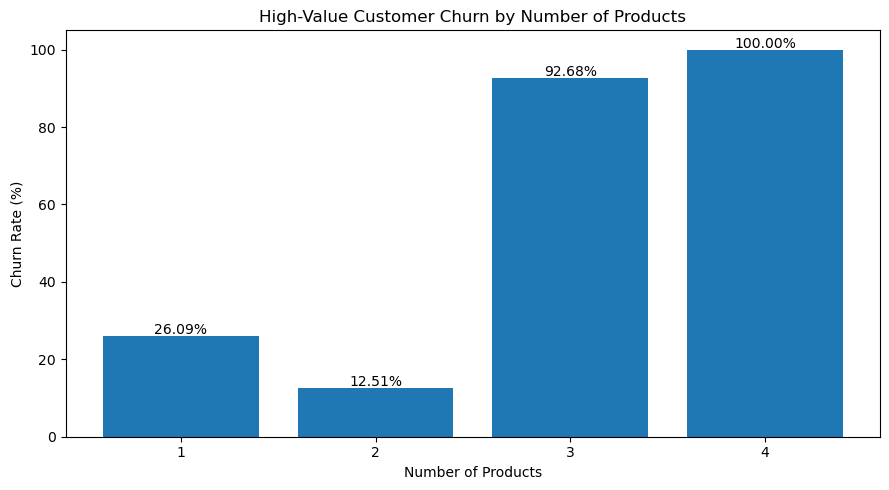

In [158]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    high_value_products.index.astype(str),
    high_value_products["Churn_Rate_%"]
)

plt.title("High-Value Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [160]:
# 6.13 — Salary vs Balance Analysis
# ==========================================
# STEP 6.13: SALARY VS BALANCE
# ==========================================

salary_balance_corr = df_seg[
    ["EstimatedSalary", "Balance"]
].corr()

salary_balance_corr

,EstimatedSalary,Balance
EstimatedSalary,1.000000,0.012797
Balance,0.012797,1.000000


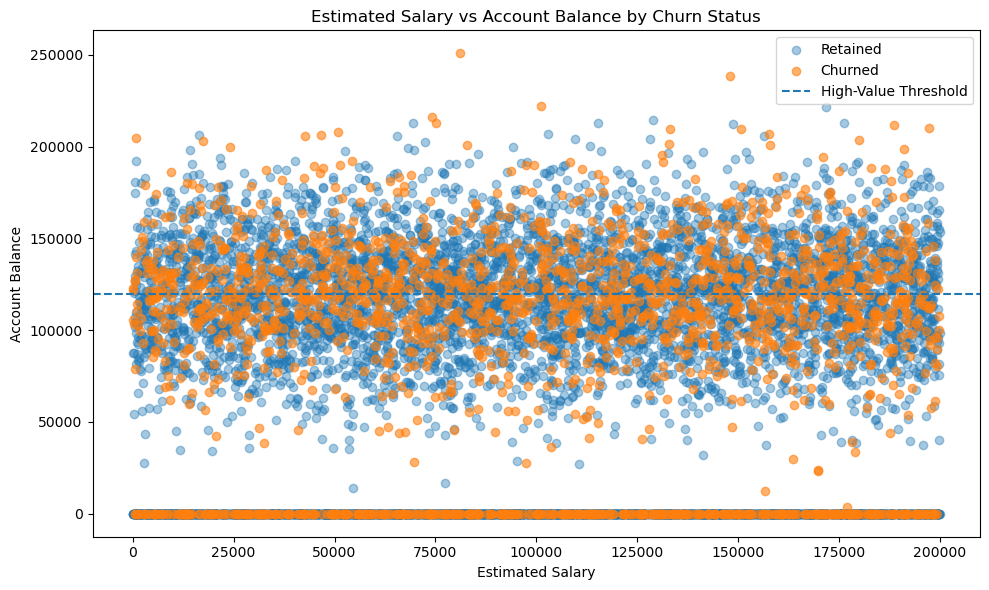

In [162]:
plt.figure(figsize=(10, 6))

retained = df_seg[df_seg["Exited"] == 0]
churned = df_seg[df_seg["Exited"] == 1]

plt.scatter(
    retained["EstimatedSalary"],
    retained["Balance"],
    alpha=0.4,
    label="Retained"
)

plt.scatter(
    churned["EstimatedSalary"],
    churned["Balance"],
    alpha=0.6,
    label="Churned"
)

plt.axhline(
    positive_balance_median,
    linestyle="--",
    label="High-Value Threshold"
)

plt.xlabel("Estimated Salary")
plt.ylabel("Account Balance")
plt.title("Estimated Salary vs Account Balance by Churn Status")
plt.legend()

plt.tight_layout()
plt.show()

In [163]:
# 6.14 — Financial Exposure from High-Value Churn
# ==========================================
# STEP 6.14: FINANCIAL EXPOSURE
# ==========================================

high_value_customers = df_seg[
    df_seg["High_Value_Flag"] == "High-Value"
]

high_value_churners = high_value_customers[
    high_value_customers["Exited"] == 1
]

total_high_value_balance = high_value_customers["Balance"].sum()

churned_high_value_balance = high_value_churners["Balance"].sum()

retained_high_value_balance = (
    high_value_customers.loc[
        high_value_customers["Exited"] == 0,
        "Balance"
    ].sum()
)

high_value_financial_exposure = pd.DataFrame({
    "Metric": [
        "Total High-Value Customers",
        "High-Value Churners",
        "Total High-Value Balance",
        "Balance Held by Churned High-Value Customers",
        "Balance Held by Retained High-Value Customers"
    ],
    "Value": [
        len(high_value_customers),
        len(high_value_churners),
        total_high_value_balance,
        churned_high_value_balance,
        retained_high_value_balance
    ]
})

high_value_financial_exposure

,Metric,Value
0,Total High-Value Customers,3.191000e+03
1,High-Value Churners,7.710000e+02
2,Total High-Value Balance,4.581541e+08
3,Balance Held by Churned High-Value Customers,1.108036e+08
4,Balance Held by Retained High-Value Customers,3.473505e+08


In [166]:
# 6.15 — High-Value Balance Exposure Percentage
high_value_balance_exposure_percentage = (
    churned_high_value_balance
    / total_high_value_balance
) * 100

print(
    f"High-Value Balance Exposure from Churned Customers: "
    f"{high_value_balance_exposure_percentage:.2f}%"
)

High-Value Balance Exposure from Churned Customers: 24.18%


In [168]:
# 6.16 — Financial Exposure by Geography
high_value_geo_exposure = (
    high_value_customers
    .groupby("Geography_Segment")
    .agg(
        High_Value_Customers=("Exited", "size"),
        High_Value_Churners=("Exited", "sum"),
        Total_Balance=("Balance", "sum")
    )
)

high_value_geo_exposure["Churned_Balance"] = (
    high_value_customers[
        high_value_customers["Exited"] == 1
    ]
    .groupby("Geography_Segment")["Balance"]
    .sum()
)

high_value_geo_exposure["Churn_Rate_%"] = (
    high_value_geo_exposure["High_Value_Churners"]
    / high_value_geo_exposure["High_Value_Customers"]
) * 100

high_value_geo_exposure["Balance_Exposure_%"] = (
    high_value_geo_exposure["Churned_Balance"]
    / high_value_geo_exposure["Total_Balance"]
) * 100

high_value_geo_exposure = high_value_geo_exposure.fillna(0).round(2)

high_value_geo_exposure

,High_Value_Customers,High_Value_Churners,Total_Balance,Churned_Balance,Churn_Rate_%,Balance_Exposure_%
Geography_Segment,,,,,,
France,1308,257,1.896991e+08,38508812.81,19.65,20.30
Germany,1248,394,1.759843e+08,53746976.14,31.57,30.54
Spain,635,120,9.247062e+07,18547806.75,18.90,20.06


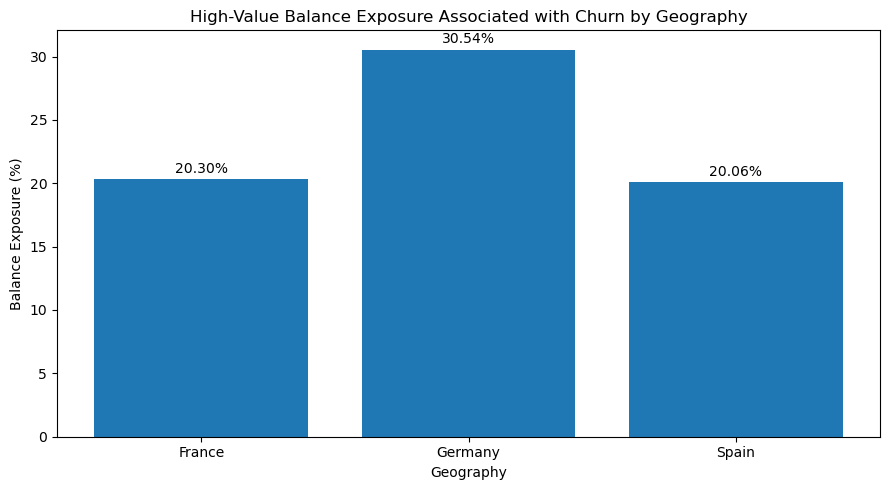

In [170]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    high_value_geo_exposure.index,
    high_value_geo_exposure["Balance_Exposure_%"]
)

plt.title("High-Value Balance Exposure Associated with Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Balance Exposure (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [172]:
# 6.17 — High-Value Churn: Geography × Age
# ==========================================
# STEP 6.17: HIGH-VALUE GEOGRAPHY × AGE
# ==========================================

high_value_geo_age = (
    df_seg[df_seg["High_Value_Flag"] == "High-Value"]
    .groupby(
        ["Geography_Segment", "Age_Segment"],
        observed=True
    )
    .agg(
        Customers=("Exited", "size"),
        Churned=("Exited", "sum")
    )
)

high_value_geo_age["Churn_Rate_%"] = (
    high_value_geo_age["Churned"]
    / high_value_geo_age["Customers"]
) * 100

high_value_geo_age = high_value_geo_age.round(2)

high_value_geo_age

Customers  Churned  Churn_Rate_%
Geography_Segment Age_Segment                                  
France            <30                226       18          7.96
                  30–45              831      127         15.28
                  46–60              194       97         50.00
                  60+                 57       15         26.32
Germany           <30                178       25         14.04
                  30–45              764      185         24.21
                  46–60              249      162         65.06
                  60+                 57       22         38.60
Spain             <30                106       15         14.15
                  30–45              387       54         13.95
                  46–60              106       43         40.57
                  60+                 36        8         22.22

In [174]:
high_value_geo_age_matrix = (
    high_value_geo_age["Churn_Rate_%"]
    .unstack()
)

high_value_geo_age_matrix

Age_Segment,<30,30–45,46–60,60+
Geography_Segment,,,,
France,7.96,15.28,50.00,26.32
Germany,14.04,24.21,65.06,38.60
Spain,14.15,13.95,40.57,22.22


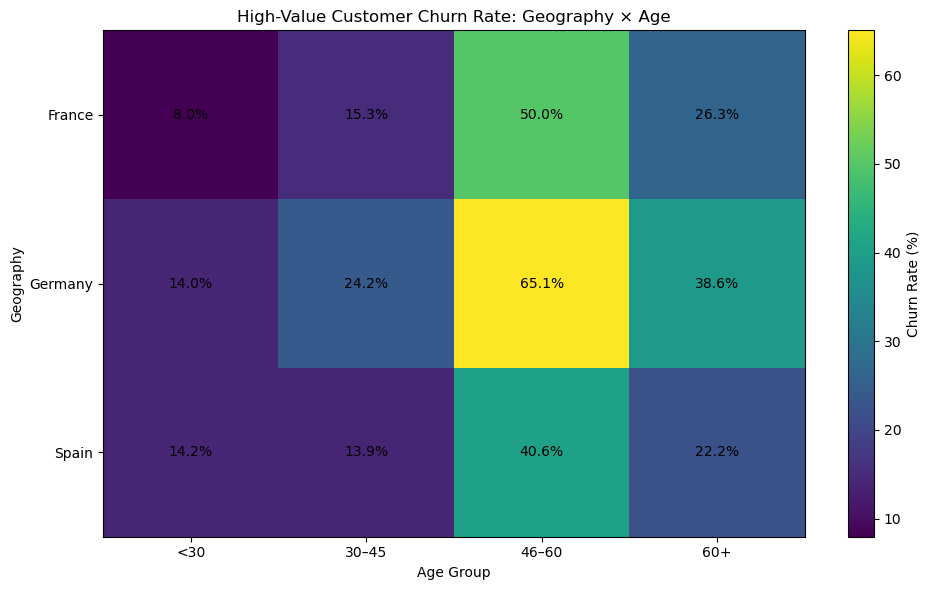

In [176]:
# 6.18 — High-Value Geography × Age Chart
plt.figure(figsize=(10, 6))

plt.imshow(
    high_value_geo_age_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(high_value_geo_age_matrix.columns)),
    high_value_geo_age_matrix.columns
)

plt.yticks(
    range(len(high_value_geo_age_matrix.index)),
    high_value_geo_age_matrix.index
)

plt.xlabel("Age Group")
plt.ylabel("Geography")
plt.title("High-Value Customer Churn Rate: Geography × Age")

for i in range(len(high_value_geo_age_matrix.index)):
    for j in range(len(high_value_geo_age_matrix.columns)):
        value = high_value_geo_age_matrix.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.colorbar(label="Churn Rate (%)")
plt.tight_layout()
plt.show()

In [178]:
# 6.19 — High-Value KPI Dashboard Table
high_value_kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "High-Value Customers",
        "High-Value Customer %",
        "High-Value Churners",
        "High-Value Churn Rate %",
        "High-Value Churn Contribution %",
        "Total High-Value Balance",
        "Churned High-Value Balance",
        "High-Value Balance Exposure %"
    ],
    "Value": [
        len(df_seg),
        len(high_value_customers),
        (len(high_value_customers) / len(df_seg)) * 100,
        len(high_value_churners),
        (len(high_value_churners) / len(high_value_customers)) * 100,
        (
            len(high_value_churners)
            / df_seg["Exited"].sum()
        ) * 100,
        total_high_value_balance,
        churned_high_value_balance,
        high_value_balance_exposure_percentage
    ]
})

high_value_kpis.round(2)

,KPI,Value
0,Total Customers,1.000000e+04
1,High-Value Customers,3.191000e+03
2,High-Value Customer %,3.191000e+01
3,High-Value Churners,7.710000e+02
4,High-Value Churn Rate %,2.416000e+01
5,High-Value Churn Contribution %,3.785000e+01
6,Total High-Value Balance,4.581541e+08
7,Churned High-Value Balance,1.108036e+08
8,High-Value Balance Exposure %,2.418000e+01


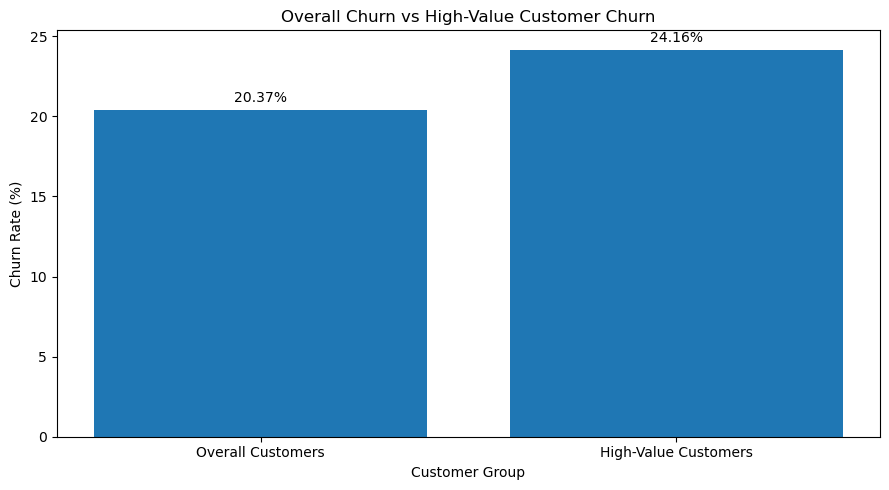

In [180]:
# 6.20 — High-Value Customer Summary Chart
comparison_metrics = pd.DataFrame({
    "Group": ["Overall Customers", "High-Value Customers"],
    "Churn Rate": [
        overall_churn_rate,
        high_value_churn.loc["High-Value", "Churn_Rate_%"]
    ]
})

plt.figure(figsize=(9, 5))

bars = plt.bar(
    comparison_metrics["Group"],
    comparison_metrics["Churn Rate"]
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Customer Group")
plt.title("Overall Churn vs High-Value Customer Churn")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [182]:
# 6.21 — Final Validation
print("Total customers:", len(df_seg))

print(
    "High-value customers:",
    (df_seg["High_Value_Flag"] == "High-Value").sum()
)

print(
    "Non-high-value customers:",
    (df_seg["High_Value_Flag"] == "Non-High-Value").sum()
)

print(
    "High-value churners:",
    (
        (df_seg["High_Value_Flag"] == "High-Value") &
        (df_seg["Exited"] == 1)
    ).sum()
)

print(
    "Unassigned High-Value flags:",
    df_seg["High_Value_Flag"].isna().sum()
)

Total customers: 10000
High-value customers: 3191
Non-high-value customers: 6809
High-value churners: 771
Unassigned High-Value flags: 0


In [186]:
# ==========================================
# STEP 7.1: OVERALL CHURN RATE
# ==========================================

total_customers = len(df_seg)

total_churned = df_seg["Exited"].sum()

total_retained = total_customers - total_churned

overall_churn_rate = (total_churned / total_customers) * 100
overall_retention_rate = (total_retained / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", total_churned)
print("Retained Customers:", total_retained)
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")
print(f"Overall Retention Rate: {overall_retention_rate:.2f}%")

Total Customers: 10000
Churned Customers: 2037
Retained Customers: 7963
Overall Churn Rate: 20.37%
Overall Retention Rate: 79.63%


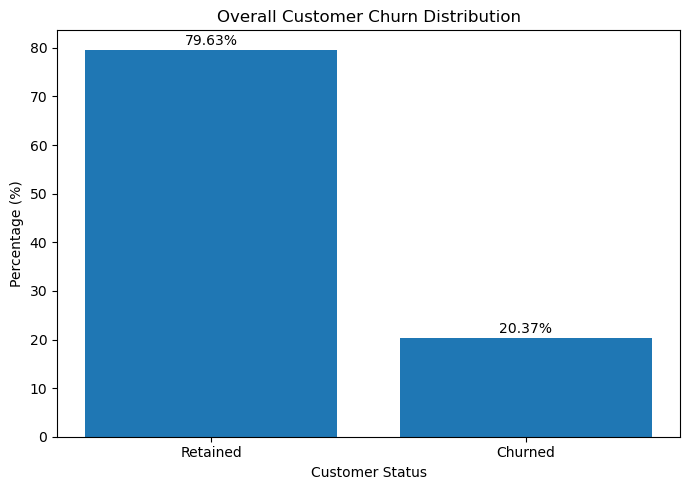

In [188]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Retained", "Churned"],
    [overall_retention_rate, overall_churn_rate]
)

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Percentage (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [190]:
# ==========================================
# STEP 7.3: SEGMENT CHURN RATE
# ==========================================

def calculate_segment_churn(df, segment_column):
    
    result = (
        df.groupby(segment_column, observed=True)
        .agg(
            Total_Customers=("Exited", "size"),
            Churned_Customers=("Exited", "sum")
        )
    )
    
    result["Churn_Rate_%"] = (
        result["Churned_Customers"]
        / result["Total_Customers"]
    ) * 100
    
    result["Difference_vs_Overall_pp"] = (
        result["Churn_Rate_%"]
        - overall_churn_rate
    )
    
    result["Relative_Churn_Index"] = (
        result["Churn_Rate_%"]
        / overall_churn_rate
    )
    
    return result.round(2)

In [192]:
geography_kpi = calculate_segment_churn(
    df_seg, "Geography_Segment"
)

age_kpi = calculate_segment_churn(
    df_seg, "Age_Segment"
)

credit_kpi = calculate_segment_churn(
    df_seg, "CreditScore_Segment"
)

tenure_kpi = calculate_segment_churn(
    df_seg, "Tenure_Segment"
)

balance_kpi = calculate_segment_churn(
    df_seg, "Balance_Segment"
)

In [194]:
print("GEOGRAPHY")
display(geography_kpi)

print("\nAGE")
display(age_kpi)

print("\nCREDIT SCORE")
display(credit_kpi)

print("\nTENURE")
display(tenure_kpi)

print("\nBALANCE")
display(balance_kpi)

GEOGRAPHY


,Total_Customers,Churned_Customers,Churn_Rate_%,Difference_vs_Overall_pp,Relative_Churn_Index
Geography_Segment,,,,,
France,5014,810,16.15,-4.22,0.79
Germany,2509,814,32.44,12.07,1.59
Spain,2477,413,16.67,-3.70,0.82



AGE


,Total_Customers,Churned_Customers,Churn_Rate_%,Difference_vs_Overall_pp,Relative_Churn_Index
Age_Segment,,,,,
<30,1641,124,7.56,-12.81,0.37
30–45,6248,956,15.30,-5.07,0.75
46–60,1647,842,51.12,30.75,2.51
60+,464,115,24.78,4.41,1.22



CREDIT SCORE


,Total_Customers,Churned_Customers,Churn_Rate_%,Difference_vs_Overall_pp,Relative_Churn_Index
CreditScore_Segment,,,,,
Low,3034,660,21.75,1.38,1.07
Medium,3818,753,19.72,-0.65,0.97
High,3148,624,19.82,-0.55,0.97



TENURE


,Total_Customers,Churned_Customers,Churn_Rate_%,Difference_vs_Overall_pp,Relative_Churn_Index
Tenure_Segment,,,,,
New,3505,741,21.14,0.77,1.04
Mid-term,2968,608,20.49,0.12,1.01
Long-term,3527,688,19.51,-0.86,0.96



BALANCE


,Total_Customers,Churned_Customers,Churn_Rate_%,Difference_vs_Overall_pp,Relative_Churn_Index
Balance_Segment,,,,,
High-balance,3191,771,24.16,3.79,1.19
Low-balance,3192,766,24.00,3.63,1.18
Zero-balance,3617,500,13.82,-6.55,0.68


In [196]:
# ==========================================
# STEP 7.4: CONSOLIDATED SEGMENT KPI
# ==========================================

segment_kpi = pd.concat([
    geography_kpi.assign(Segment_Type="Geography"),
    age_kpi.assign(Segment_Type="Age"),
    credit_kpi.assign(Segment_Type="Credit Score"),
    tenure_kpi.assign(Segment_Type="Tenure"),
    balance_kpi.assign(Segment_Type="Balance")
])

segment_kpi = (
    segment_kpi
    .reset_index()
    .rename(columns={"index": "Segment"})
)

segment_kpi = segment_kpi[
    [
        "Segment_Type",
        "Segment",
        "Total_Customers",
        "Churned_Customers",
        "Churn_Rate_%",
        "Difference_vs_Overall_pp",
        "Relative_Churn_Index"
    ]
]

segment_kpi

,Segment_Type,Segment,Total_Customers,Churned_Customers,Churn_Rate_%,Difference_vs_Overall_pp,Relative_Churn_Index
0,Geography,France,5014,810,16.15,-4.22,0.79
1,Geography,Germany,2509,814,32.44,12.07,1.59
2,Geography,Spain,2477,413,16.67,-3.70,0.82
3,Age,<30,1641,124,7.56,-12.81,0.37
4,Age,30–45,6248,956,15.30,-5.07,0.75
5,Age,46–60,1647,842,51.12,30.75,2.51
6,Age,60+,464,115,24.78,4.41,1.22
7,Credit Score,Low,3034,660,21.75,1.38,1.07
8,Credit Score,Medium,3818,753,19.72,-0.65,0.97
9,Credit Score,High,3148,624,19.82,-0.55,0.97


In [198]:
# ==========================================
# STEP 7.5: HIGH-VALUE CHURN RATIO
# ==========================================

high_value_customers_count = (
    df_seg["High_Value_Flag"] == "High-Value"
).sum()

high_value_churners_count = (
    (df_seg["High_Value_Flag"] == "High-Value") &
    (df_seg["Exited"] == 1)
).sum()

high_value_churn_ratio = (
    high_value_churners_count
    / high_value_customers_count
) * 100

print("High-Value Customers:", high_value_customers_count)
print("High-Value Churners:", high_value_churners_count)
print(
    f"High-Value Churn Ratio: "
    f"{high_value_churn_ratio:.2f}%"
)

High-Value Customers: 3191
High-Value Churners: 771
High-Value Churn Ratio: 24.16%


In [200]:
high_value_difference_pp = (
    high_value_churn_ratio
    - overall_churn_rate
)

high_value_relative_index = (
    high_value_churn_ratio
    / overall_churn_rate
)

print(
    f"High-Value Churn Difference: "
    f"{high_value_difference_pp:.2f} percentage points"
)

print(
    f"High-Value Relative Churn Index: "
    f"{high_value_relative_index:.2f}"
)

High-Value Churn Difference: 3.79 percentage points
High-Value Relative Churn Index: 1.19


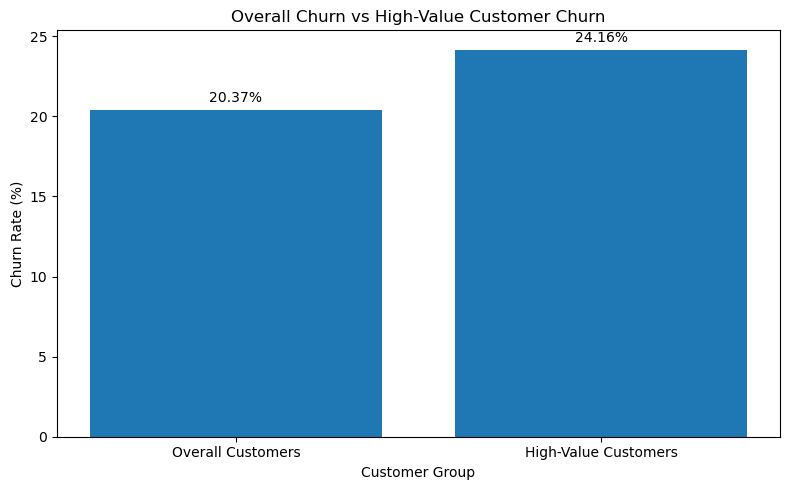

In [202]:
plt.figure(figsize=(8, 5))

groups = [
    "Overall Customers",
    "High-Value Customers"
]

rates = [
    overall_churn_rate,
    high_value_churn_ratio
]

bars = plt.bar(groups, rates)

plt.title("Overall Churn vs High-Value Customer Churn")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [204]:
# ==========================================
# STEP 7.8: GEOGRAPHIC RISK INDEX
# ==========================================

geographic_risk = geography_kpi[
    [
        "Total_Customers",
        "Churned_Customers",
        "Churn_Rate_%",
        "Relative_Churn_Index"
    ]
].copy()

geographic_risk = geographic_risk.rename(
    columns={
        "Relative_Churn_Index": "Geographic_Risk_Index"
    }
)

geographic_risk

,Total_Customers,Churned_Customers,Churn_Rate_%,Geographic_Risk_Index
Geography_Segment,,,,
France,5014,810,16.15,0.79
Germany,2509,814,32.44,1.59
Spain,2477,413,16.67,0.82


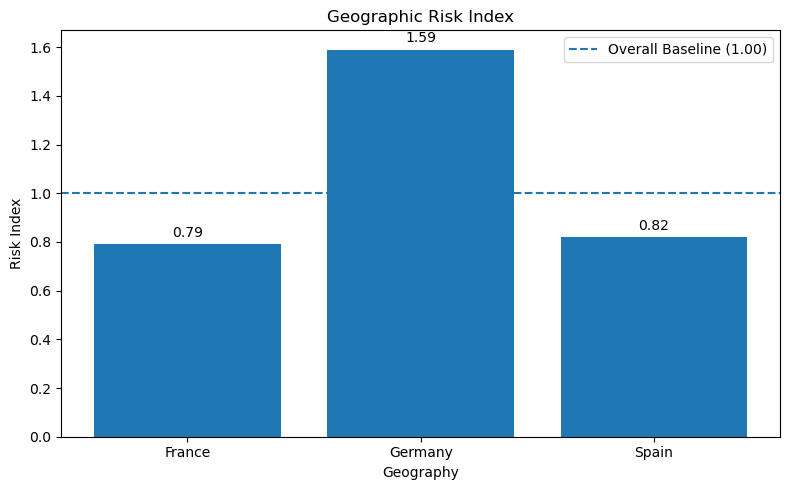

In [206]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    geographic_risk.index,
    geographic_risk["Geographic_Risk_Index"]
)

plt.axhline(
    1.0,
    linestyle="--",
    label="Overall Baseline (1.00)"
)

plt.title("Geographic Risk Index")
plt.xlabel("Geography")
plt.ylabel("Risk Index")
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [208]:
# ==========================================
# STEP 7.10: ENGAGEMENT ANALYSIS
# ==========================================

activity_churn = (
    df_seg.groupby("Activity_Group")
    .agg(
        Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

activity_churn["Churn_Rate_%"] = (
    activity_churn["Churned_Customers"]
    / activity_churn["Customers"]
) * 100

activity_churn = activity_churn.round(2)

activity_churn

,Customers,Churned_Customers,Churn_Rate_%
Activity_Group,,,
Active,5151,735,14.27
Inactive,4849,1302,26.85


In [210]:
active_churn_rate = activity_churn.loc[
    "Active", "Churn_Rate_%"
]

inactive_churn_rate = activity_churn.loc[
    "Inactive", "Churn_Rate_%"
]

engagement_drop_pp = (
    inactive_churn_rate
    - active_churn_rate
)

engagement_churn_ratio = (
    inactive_churn_rate
    / active_churn_rate
)

print(f"Active Member Churn Rate: {active_churn_rate:.2f}%")
print(f"Inactive Member Churn Rate: {inactive_churn_rate:.2f}%")

print(
    f"Engagement Drop Indicator: "
    f"{engagement_drop_pp:.2f} percentage points"
)

print(
    f"Inactive-to-Active Churn Ratio: "
    f"{engagement_churn_ratio:.2f}"
)

Active Member Churn Rate: 14.27%
Inactive Member Churn Rate: 26.85%
Engagement Drop Indicator: 12.58 percentage points
Inactive-to-Active Churn Ratio: 1.88


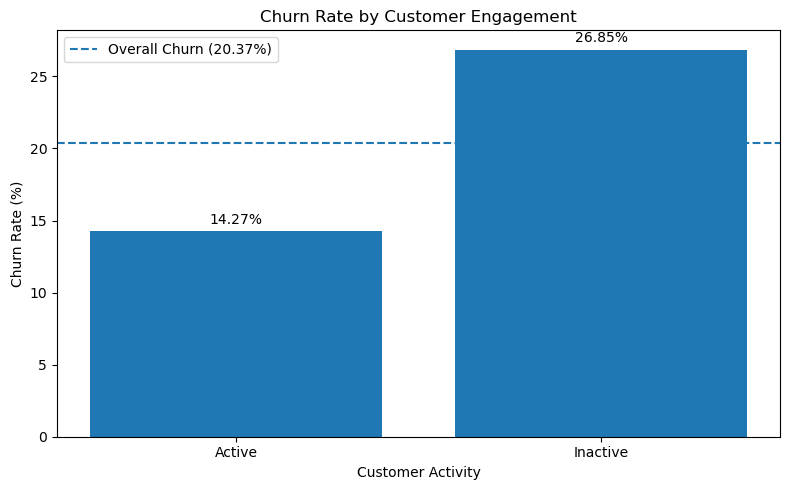

In [212]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    activity_churn.index,
    activity_churn["Churn_Rate_%"]
)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Customer Engagement")
plt.xlabel("Customer Activity")
plt.ylabel("Churn Rate (%)")
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [214]:
# ==========================================
# STEP 7.13: HIGH-VALUE ENGAGEMENT KPI
# ==========================================

high_value_activity = (
    df_seg[df_seg["High_Value_Flag"] == "High-Value"]
    .groupby("Activity_Group")
    .agg(
        Customers=("Exited", "size"),
        Churned_Customers=("Exited", "sum")
    )
)

high_value_activity["Churn_Rate_%"] = (
    high_value_activity["Churned_Customers"]
    / high_value_activity["Customers"]
) * 100

high_value_activity = high_value_activity.round(2)

high_value_activity

,Customers,Churned_Customers,Churn_Rate_%
Activity_Group,,,
Active,1622,281,17.32
Inactive,1569,490,31.23


In [216]:
hv_active_rate = high_value_activity.loc[
    "Active", "Churn_Rate_%"
]

hv_inactive_rate = high_value_activity.loc[
    "Inactive", "Churn_Rate_%"
]

hv_engagement_gap = (
    hv_inactive_rate - hv_active_rate
)

print(
    f"High-Value Engagement Drop Indicator: "
    f"{hv_engagement_gap:.2f} percentage points"
)

High-Value Engagement Drop Indicator: 13.91 percentage points


In [218]:
# ==========================================
# STEP 7.14: HIGHEST CHURN SEGMENTS
# ==========================================

highest_churn_segments = pd.DataFrame({
    "Segment_Type": [
        "Geography",
        "Age",
        "Credit Score",
        "Tenure",
        "Balance"
    ],
    "Segment": [
        geography_kpi["Churn_Rate_%"].idxmax(),
        age_kpi["Churn_Rate_%"].idxmax(),
        credit_kpi["Churn_Rate_%"].idxmax(),
        tenure_kpi["Churn_Rate_%"].idxmax(),
        balance_kpi["Churn_Rate_%"].idxmax()
    ],
    "Churn_Rate_%": [
        geography_kpi["Churn_Rate_%"].max(),
        age_kpi["Churn_Rate_%"].max(),
        credit_kpi["Churn_Rate_%"].max(),
        tenure_kpi["Churn_Rate_%"].max(),
        balance_kpi["Churn_Rate_%"].max()
    ]
})

highest_churn_segments

,Segment_Type,Segment,Churn_Rate_%
0,Geography,Germany,32.44
1,Age,46–60,51.12
2,Credit Score,Low,21.75
3,Tenure,New,21.14
4,Balance,High-balance,24.16


In [220]:
# ==========================================
# STEP 7.15: CHURN CONTRIBUTION
# ==========================================

def calculate_churn_contribution(df, segment_column):
    
    result = (
        df.groupby(segment_column, observed=True)
        .agg(
            Customers=("Exited", "size"),
            Churned_Customers=("Exited", "sum")
        )
    )
    
    result["Churn_Contribution_%"] = (
        result["Churned_Customers"]
        / df["Exited"].sum()
    ) * 100
    
    return result.round(2)

In [222]:
geography_contribution = calculate_churn_contribution(
    df_seg, "Geography_Segment"
)

age_contribution = calculate_churn_contribution(
    df_seg, "Age_Segment"
)

credit_contribution = calculate_churn_contribution(
    df_seg, "CreditScore_Segment"
)

tenure_contribution = calculate_churn_contribution(
    df_seg, "Tenure_Segment"
)

balance_contribution = calculate_churn_contribution(
    df_seg, "Balance_Segment"
)

In [224]:
largest_contributors = pd.DataFrame({
    "Segment_Type": [
        "Geography",
        "Age",
        "Credit Score",
        "Tenure",
        "Balance"
    ],
    "Segment": [
        geography_contribution["Churn_Contribution_%"].idxmax(),
        age_contribution["Churn_Contribution_%"].idxmax(),
        credit_contribution["Churn_Contribution_%"].idxmax(),
        tenure_contribution["Churn_Contribution_%"].idxmax(),
        balance_contribution["Churn_Contribution_%"].idxmax()
    ],
    "Churn_Contribution_%": [
        geography_contribution["Churn_Contribution_%"].max(),
        age_contribution["Churn_Contribution_%"].max(),
        credit_contribution["Churn_Contribution_%"].max(),
        tenure_contribution["Churn_Contribution_%"].max(),
        balance_contribution["Churn_Contribution_%"].max()
    ]
})

largest_contributors

,Segment_Type,Segment,Churn_Contribution_%
0,Geography,Germany,39.96
1,Age,30–45,46.93
2,Credit Score,Medium,36.97
3,Tenure,New,36.38
4,Balance,High-balance,37.85


In [226]:
# ==========================================
# STEP 7.16: FINAL KPI DASHBOARD
# ==========================================

kpi_dashboard = pd.DataFrame({
    "KPI": [
        "Overall Churn Rate",
        "High-Value Churn Ratio",
        "Geographic Risk Index - Germany",
        "Engagement Drop Indicator",
        "High-Value Balance Exposure %"
    ],
    "Value": [
        overall_churn_rate,
        high_value_churn_ratio,
        geographic_risk.loc["Germany", "Geographic_Risk_Index"],
        engagement_drop_pp,
        high_value_balance_exposure_percentage
    ],
    "Unit": [
        "%",
        "%",
        "Index",
        "Percentage Points",
        "%"
    ]
})

kpi_dashboard["Value"] = kpi_dashboard["Value"].round(2)

kpi_dashboard

,KPI,Value,Unit
0,Overall Churn Rate,20.37,%
1,High-Value Churn Ratio,24.16,%
2,Geographic Risk Index - Germany,1.59,Index
3,Engagement Drop Indicator,12.58,Percentage Points
4,High-Value Balance Exposure %,24.18,%


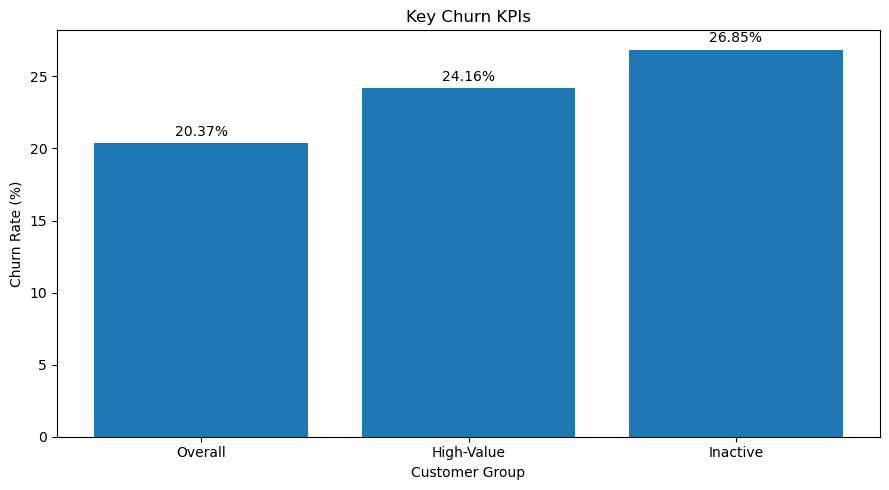

In [228]:
plt.figure(figsize=(9, 5))

kpi_names = [
    "Overall",
    "High-Value",
    "Inactive"
]

kpi_values = [
    overall_churn_rate,
    high_value_churn_ratio,
    inactive_churn_rate
]

bars = plt.bar(kpi_names, kpi_values)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Customer Group")
plt.title("Key Churn KPIs")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [230]:
# 7.18 — Save KPI Tables for Future Streamlit Use
# Save important KPI outputs

kpi_outputs = {
    "overall_churn_rate": overall_churn_rate,
    "high_value_churn_ratio": high_value_churn_ratio,
    "geographic_risk": geographic_risk,
    "engagement_drop_pp": engagement_drop_pp,
    "high_value_balance_exposure": high_value_balance_exposure_percentage
}

kpi_outputs

{'overall_churn_rate': 20.369999999999997,
 'high_value_churn_ratio': 24.161704794735194,
 'geographic_risk':                    Total_Customers  Churned_Customers  Churn_Rate_%  \
 Geography_Segment                                                     
 France                        5014                810         16.15   
 Germany                       2509                814         32.44   
 Spain                         2477                413         16.67   
 
                    Geographic_Risk_Index  
 Geography_Segment                         
 France                              0.79  
 Germany                             1.59  
 Spain                               0.82  ,
 'engagement_drop_pp': 12.580000000000002,
 'high_value_balance_exposure': 24.18478957115807}

In [232]:
# 7.19 — Final Validation
print("========== FINAL KPI VALIDATION ==========")

print(f"Total Customers: {total_customers}")
print(f"Total Churned: {total_churned}")
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")

print(
    f"High-Value Customers: "
    f"{high_value_customers_count}"
)

print(
    f"High-Value Churners: "
    f"{high_value_churners_count}"
)

print(
    f"High-Value Churn Ratio: "
    f"{high_value_churn_ratio:.2f}%"
)

print(
    f"Germany Geographic Risk Index: "
    f"{geographic_risk.loc['Germany', 'Geographic_Risk_Index']:.2f}"
)

print(
    f"Engagement Drop Indicator: "
    f"{engagement_drop_pp:.2f} percentage points"
)

print(
    f"High-Value Balance Exposure: "
    f"{high_value_balance_exposure_percentage:.2f}%"
)

========== FINAL KPI VALIDATION ==========
Total Customers: 10000
Total Churned: 2037
Overall Churn Rate: 20.37%
High-Value Customers: 3191
High-Value Churners: 771
High-Value Churn Ratio: 24.16%
Germany Geographic Risk Index: 1.59
Engagement Drop Indicator: 12.58 percentage points
High-Value Balance Exposure: 24.18%
